# Method results

Per-method report card. Pick one `METHOD` in the first cell; everything below runs for that method only.

Sections:
1. Simulation results
2. Classifier results
3. Stability diagnostics from resampling
4. Final protein list + enrichment

In [23]:
METHOD = "mi"   # change this to switch the whole notebook

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.styles.colors import CATEGORICAL, PALETTE, SEQUENTIAL_TEAL, SEQUENTIAL_ORANGE
from src.statistics import nadeau_bengio_se

sns.set_theme(style="whitegrid", context="notebook")

RESULTS = REPO_ROOT / "results"
DATA_PROCESSED = REPO_ROOT / "data" / "processed"

STAGE_DIRS = {
    "simulation": RESULTS / "simulation" / METHOD,
    "classifier": RESULTS / "classifier" / METHOD,
    "selection":  RESULTS / "selection" / METHOD,
    "enrichment": RESULTS / "enrichment" / METHOD,
}
missing = [s for s, p in STAGE_DIRS.items() if not p.exists()]
assert not missing, f"Missing result directories for METHOD={METHOD!r}: {missing}"

def load_meta(path: Path) -> dict:
    with open(path) as f:
        return json.load(f)

splits_meta = load_meta(DATA_PROCESSED / "splits_meta.json")
TEST_SIZE = float(splits_meta["test_size"])
N_SAMPLES = int(splits_meta["n_samples"])
N_TEST = int(round(TEST_SIZE * N_SAMPLES))
N_TRAIN = N_SAMPLES - N_TEST

print(f"METHOD = {METHOD}")
for stage, path in STAGE_DIRS.items():
    print(f"  {stage:<10s} -> {path.relative_to(REPO_ROOT)}")
print(
    f"Nadeau-Bengio: n_samples={N_SAMPLES} test_size={TEST_SIZE:.4f} "
    f"-> n_train={N_TRAIN} n_test={N_TEST} (ratio={N_TEST / N_TRAIN:.4f})"
)

METHOD = mi
  simulation -> results\simulation\mi
  classifier -> results\classifier\mi
  selection  -> results\selection\mi
  enrichment -> results\enrichment\mi
Nadeau-Bengio: n_samples=512 test_size=0.2000 -> n_train=410 n_test=102 (ratio=0.2488)


In [24]:
sel_meta = load_meta(STAGE_DIRS["selection"] / "meta.json")
full_meta = load_meta(STAGE_DIRS["selection"] / "full_data_meta.json")
sim_meta = load_meta(STAGE_DIRS["simulation"] / "meta.json")
clf_meta = load_meta(STAGE_DIRS["classifier"] / "meta.json")

header = pd.DataFrame({
    "stage":   ["selection (resampling)", "selection (full data)", "simulation", "classifier"],
    "n_samples":   [sel_meta.get("n_samples"),  full_meta.get("n_samples"),  sim_meta.get("n_samples"),  clf_meta.get("n_samples")],
    "n_proteins":  [sel_meta.get("n_proteins"), full_meta.get("n_proteins"), sim_meta.get("n_proteins"), clf_meta.get("n_proteins")],
    "n_splits":    [sel_meta.get("n_splits"),   None,                         None,                        clf_meta.get("n_splits")],
    "n_significant": [sel_meta.get("method_params", {}).get("n_significant"),
                      full_meta.get("n_significant"),
                      None,
                      None],
    "seed":        [sel_meta.get("seed"), full_meta.get("seed"), sim_meta.get("seed"), clf_meta.get("seed")],
})
header

,stage,n_samples,n_proteins,n_splits,n_significant,seed
0,selection (resampling),512.0,10776.0,50.0,NaN,42
1,selection (full data),512.0,10776.0,NaN,0.0,42
2,simulation,500.0,NaN,NaN,NaN,42
3,classifier,NaN,NaN,50.0,NaN,42


## 1. Simulation results

Synthetic-signal recovery under controlled effect sizes. Higher `recall` at fixed `k` is better; lower `fdp` is better.

In [25]:
recall_df = pd.read_parquet(STAGE_DIRS["simulation"] / "recall.parquet")
fdp_df = pd.read_parquet(STAGE_DIRS["simulation"] / "fdp.parquet")
print(
    f"recall: {len(recall_df):,} rows | repeats={recall_df['repeat'].nunique()} | "
    f"signal_types={sorted(recall_df['signal_type'].unique())} | "
    f"effect_sizes={sorted(recall_df['effect_size'].unique())} | k={sorted(recall_df['k'].unique())}"
)
print(
    f"fdp:    {len(fdp_df):,} rows | repeats={fdp_df['repeat'].nunique()} | k={sorted(fdp_df['k'].unique())}"
)
recall_df.head(10)

recall: 750 rows | repeats=10 | signal_types=['bounded_variance', 'linear', 'threshold', 'u_shape', 'xor_pair'] | effect_sizes=[np.float64(0.3), np.float64(0.6), np.float64(1.0)] | k=['10', '100', '25', '50', 'native']
fdp:    50 rows | repeats=10 | k=['10', '100', '25', '50', 'native']


,repeat,signal_type,effect_size,k,recall,block_recall
0,1,bounded_variance,0.3,10,0.000000,0.000000
1,1,bounded_variance,0.3,100,0.000000,0.000000
2,1,bounded_variance,0.3,25,0.000000,0.000000
3,1,bounded_variance,0.3,50,0.000000,0.000000
4,1,bounded_variance,0.3,native,0.000000,0.000000
5,1,bounded_variance,0.6,10,0.000000,0.000000
6,1,bounded_variance,0.6,100,0.333333,0.666667
7,1,bounded_variance,0.6,25,0.000000,0.000000
8,1,bounded_variance,0.6,50,0.000000,0.000000
9,1,bounded_variance,0.6,native,0.000000,0.000000


In [26]:
recall_summary = (
    recall_df.groupby(["signal_type", "effect_size", "k"], as_index=False)
       .agg(recall_mean=("recall", "mean"), recall_std=("recall", "std"),
            n=("recall", "size"))
)
recall_summary.round(3)

,signal_type,effect_size,k,recall_mean,recall_std,n
0,bounded_variance,0.3,10,0.000,0.000,10
1,bounded_variance,0.3,100,0.033,0.105,10
2,bounded_variance,0.3,25,0.000,0.000,10
3,bounded_variance,0.3,50,0.000,0.000,10
4,bounded_variance,0.3,native,0.000,0.000,10
...,...,...,...,...,...,...
70,xor_pair,1.0,10,0.000,0.000,10
71,xor_pair,1.0,100,0.000,0.000,10
72,xor_pair,1.0,25,0.000,0.000,10
73,xor_pair,1.0,50,0.000,0.000,10


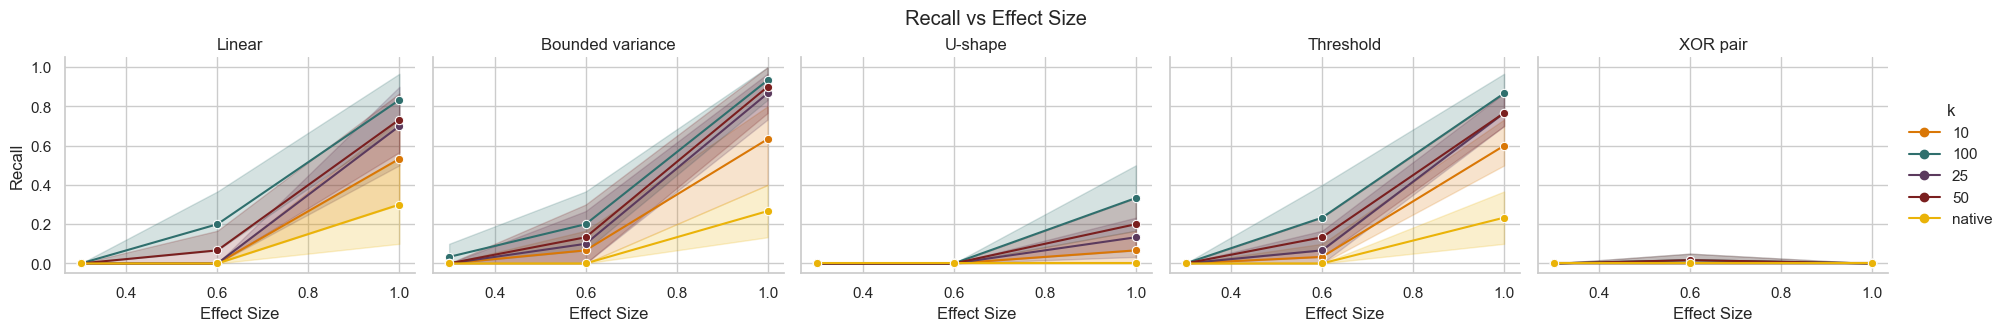

In [27]:
k_values = sorted(recall_df["k"].unique())
palette_k = dict(zip(k_values, CATEGORICAL[:len(k_values)]))

desired_signal_order = ["linear", "bounded_variance", "u_shape", "threshold", "xor_pair"]
existing_signal_types = list(pd.unique(recall_df["signal_type"]))
signal_order = [s for s in desired_signal_order if s in existing_signal_types]
signal_order += [s for s in existing_signal_types if s not in signal_order]

g = sns.relplot(
    data=recall_df, kind="line",
    x="effect_size", y="recall", hue="k", col="signal_type",
    col_order=signal_order,
    palette=palette_k, marker="o", errorbar=("ci", 95), height=3.2, aspect=1.2,
    facet_kws={"sharey": True},
)
g.set_axis_labels("Effect Size", "Recall")
g.set_titles(col_template="{col_name}")

title_map = {
    "linear": "Linear",
    "bounded_variance": "Bounded variance",
    "threshold": "Threshold",
    "u_shape": "U-shape",
    "xor_pair": "XOR pair",
}
for ax in g.axes.flat:
    raw_title = ax.get_title()
    if raw_title in title_map:
        ax.set_title(title_map[raw_title])
    else:
        fallback = raw_title.replace("_", " ").replace("-", " ")
        ax.set_title(fallback[:1].upper() + fallback[1:] if fallback else fallback)

g.fig.suptitle("Recall vs Effect Size", y=1.03)
plt.show()

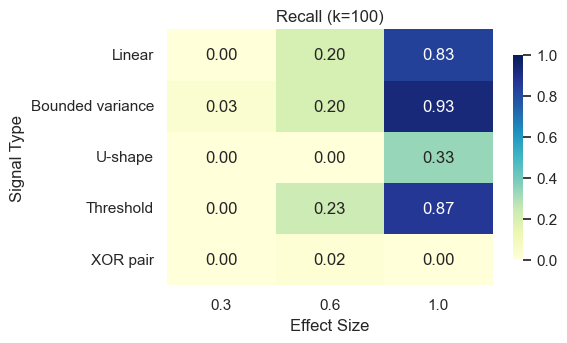

In [28]:
k = "100"
sim_native = recall_df[recall_df["k"] == k]

title_map = {
    "linear": "Linear",
    "bounded_variance": "Bounded variance",
    "threshold": "Threshold",
    "u_shape": "U-shape",
    "xor_pair": "XOR pair",
}

fig, ax = plt.subplots(figsize=(6, 3.6))
pivot = (
    sim_native.groupby(["signal_type", "effect_size"])["recall"].mean()
    .unstack("effect_size")
)
pivot.rename(index=title_map, inplace=True)
pivot = pivot.reindex([title_map[s] for s in signal_order if s in title_map])
sns.heatmap(
    pivot, annot=True, fmt=".2f", cmap="YlGnBu",
    ax=ax, vmin=0, vmax=1, cbar_kws={"shrink": 0.8}
 )
ax.set_title(f"Recall (k={k})")
ax.set_xlabel("Effect Size")
ax.set_ylabel("Signal Type")
fig.tight_layout()
plt.show()

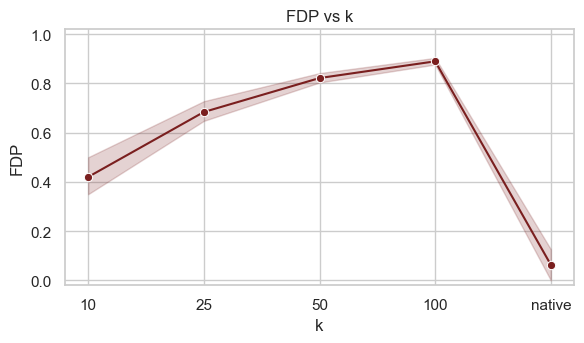

,k,fdp_mean,fdp_std,n_selected_mean
0,10,0.420,0.132,10.0
1,25,0.684,0.067,25.0
2,50,0.822,0.035,50.0
3,100,0.890,0.023,100.0
4,native,0.063,0.095,2.7


In [29]:
# FDP is per (repeat, k) — one independent observation per repeat. CIs reflect 50 reps, not 750 duplicates.
def _k_sort_key(value):
    s = str(value).strip().lower()
    if s == "native":
        return (2, float("inf"))
    try:
        return (0, float(s))
    except ValueError:
        return (1, s)

k_order = sorted(pd.unique(fdp_df["k"]), key=_k_sort_key)
#k_order = k_order[:-1]

fdp_plot = fdp_df.copy()
fdp_plot["k"] = pd.Categorical(fdp_plot["k"], categories=k_order, ordered=True)
fdp_plot = fdp_plot.sort_values("k")

fig, ax = plt.subplots(figsize=(6, 3.6))
sns.lineplot(
    data=fdp_plot, x="k", y="fdp", estimator="mean", errorbar=("ci", 95),
    marker="o", color=PALETTE["danger"], ax=ax,
)
ax.set_title(f"FDP vs k")
ax.set_xlabel("k")
ax.set_ylabel("FDP")
ax.set_ylim(-0.02, 1.02)
fig.tight_layout()
plt.show()

(
    fdp_plot.groupby("k", as_index=False, sort=False, observed=True)
    .agg(fdp_mean=("fdp", "mean"), fdp_std=("fdp", "std"),
         n_selected_mean=("n_selected", "mean"))
    .round(3)
)

## 2. Classifier results

Downstream classifier performance when trained on the top-k features selected by this method on each resampled split.

`auc_se_nb` / `aupr_se_nb` are Nadeau–Bengio corrected standard errors of the mean across the random 80/20 splits, accounting for shared test patients across folds. `auc_sd_split` / `aupr_sd_split` show the raw split-to-split spread (variability of the per-split metric, not population SE).

In [30]:
clf = pd.read_parquet(STAGE_DIRS["classifier"] / "scores.parquet")
print(f"{len(clf):,} rows | splits={clf['split_id'].nunique()} | classifiers={sorted(clf['classifier'].unique())} | "
      f"k={sorted(clf['k'].unique())}")
clf.head()

750 rows | splits=50 | classifiers=['LogisticRegression', 'RandomForest', 'XGBoost'] | k=['10', '100', '25', '50', 'native']


,split_id,classifier,k,auc,aupr,n_features_actual
0,0,LogisticRegression,10,0.521212,0.166125,10
1,0,RandomForest,10,0.594697,0.238838,10
2,0,XGBoost,10,0.663636,0.322615,10
3,0,LogisticRegression,25,0.646212,0.248957,25
4,0,RandomForest,25,0.630303,0.332221,25


In [31]:
clf_summary = (
    clf.groupby(["classifier", "k"], as_index=False)
       .agg(auc_mean=("auc", "mean"), auc_sd_split=("auc", "std"),
            aupr_mean=("aupr", "mean"), aupr_sd_split=("aupr", "std"),
            n_splits=("split_id", "nunique"),
            n=("auc", "size"))
       .sort_values(["classifier", "k"])
)
clf_summary["auc_se_nb"] = clf_summary.apply(
    lambda r: nadeau_bengio_se(r["auc_sd_split"], int(r["n_splits"]), N_TRAIN, N_TEST),
    axis=1,
)
clf_summary["aupr_se_nb"] = clf_summary.apply(
    lambda r: nadeau_bengio_se(r["aupr_sd_split"], int(r["n_splits"]), N_TRAIN, N_TEST),
    axis=1,
)
clf_summary.round(3).style.background_gradient(subset=["auc_mean", "aupr_mean"], cmap="YlGnBu")

,classifier,k,auc_mean,auc_sd_split,aupr_mean,aupr_sd_split,n_splits,n,auc_se_nb,aupr_se_nb
0,LogisticRegression,10,0.533000,0.088000,0.200000,0.065000,50,50,0.045000,0.034000
1,LogisticRegression,100,0.587000,0.088000,0.227000,0.064000,50,50,0.045000,0.033000
2,LogisticRegression,25,0.560000,0.093000,0.216000,0.071000,50,50,0.048000,0.037000
3,LogisticRegression,50,0.588000,0.085000,0.229000,0.073000,50,50,0.044000,0.038000
4,LogisticRegression,native,0.505000,nan,0.147000,nan,50,50,nan,nan
5,RandomForest,10,0.554000,0.087000,0.205000,0.058000,50,50,0.045000,0.030000
6,RandomForest,100,0.599000,0.071000,0.222000,0.061000,50,50,0.037000,0.032000
7,RandomForest,25,0.568000,0.086000,0.223000,0.074000,50,50,0.045000,0.038000
8,RandomForest,50,0.593000,0.075000,0.232000,0.070000,50,50,0.039000,0.036000
9,RandomForest,native,0.472000,nan,0.147000,nan,50,50,nan,nan


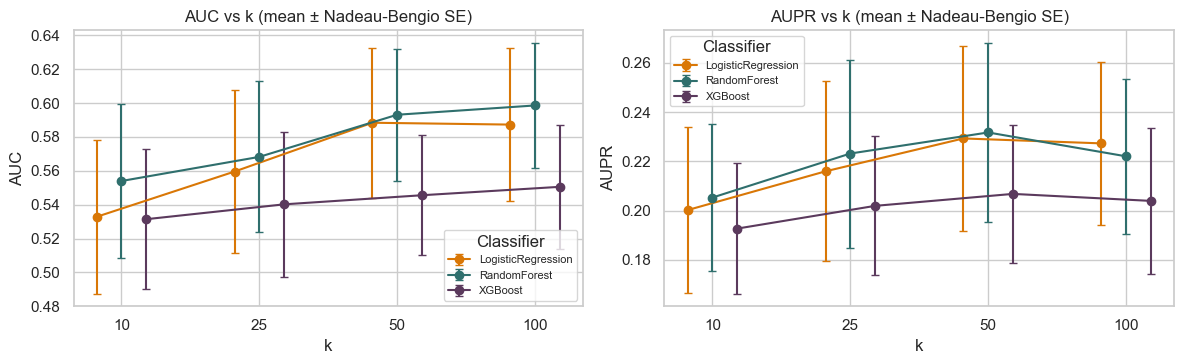

In [32]:
classifier_order = sorted(clf["classifier"].unique())
palette_clf = dict(zip(classifier_order, CATEGORICAL[:len(classifier_order)]))

# Build a k order that prefers [10, 25, 100, native] when present,
# then appends any remaining k values preserving their observed order.
k_unique = list(pd.unique(clf["k"]))
def _find_k(s):
    for v in k_unique:
        if str(v).strip().lower() == str(s).strip().lower():
            return v
    return None
desired = ['10', '25', '50', '100', 'native']
k_order_clf = [v for s in desired if (v := _find_k(s)) is not None]
k_order_clf += [v for v in k_unique if v not in k_order_clf]
k_order_clf = k_order_clf[:-1]  # remove 'native' to avoid overcrowding the plot
x_positions = np.arange(len(k_order_clf))
dodge = 0.18

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
for ax, metric, ylabel in [(axes[0], "auc", "AUC"), (axes[1], "aupr", "AUPR")]:
    mean_col = f"{metric}_mean"
    se_col = f"{metric}_se_nb"
    for i, clf_name in enumerate(classifier_order):
        sub = clf_summary[clf_summary["classifier"] == clf_name].set_index("k")
        y = [sub.loc[k, mean_col] if k in sub.index else np.nan for k in k_order_clf]
        yerr = [sub.loc[k, se_col] if k in sub.index else np.nan for k in k_order_clf]
        offset = (i - (len(classifier_order) - 1) / 2) * dodge
        ax.errorbar(
            x_positions + offset,
            y,
            yerr=yerr,
            fmt="o-",
            color=palette_clf[clf_name],
            label=clf_name,
            capsize=3,
        )
    ax.set_ylabel(ylabel)
    ax.set_xlabel("k")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(k_order_clf)
    ax.set_title(f"{ylabel} vs k (mean ± Nadeau-Bengio SE)")
    ax.legend(title="Classifier", fontsize=8)
fig.tight_layout()
plt.show()

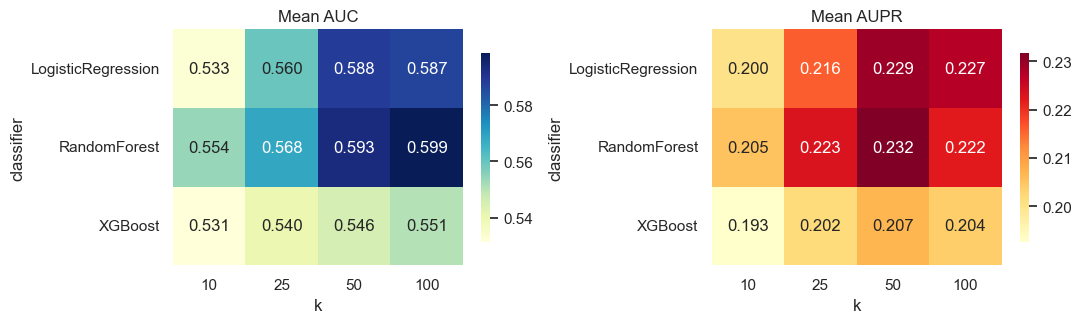

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, metric, cmap, title in [
    (axes[0], "auc",  "YlGnBu", "Mean AUC"),
    (axes[1], "aupr", "YlOrRd", "Mean AUPR"),
]:
    drop_native = True  # set to False to keep k="native"

    pivot = clf.groupby(["classifier", "k"])[metric].mean().unstack("k")
    if drop_native and "native" in pivot.columns:
        pivot = pivot.drop(columns="native")
    cols = [k for k in k_order_clf if not (drop_native and str(k).lower() == "native")]
    pivot = pivot.reindex(index=classifier_order, columns=cols)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{title}")
fig.tight_layout()
plt.show()

## 3. Stability diagnostics

How often each protein was selected across the resampled splits.
- `stability_significant.parquet` â€” frequency under the significance-threshold rule
- `stability_topk.parquet` â€” frequency for k âˆˆ {10, 25, 50, 100}

At the end of this section we overlay the final protein list (from Section 4) on the stability curves, so you can see whether the final picks came from the stable tail or not.

In [34]:
stab_sig = pd.read_parquet(STAGE_DIRS["selection"] / "stability_significant.parquet")
stab_topk = pd.read_parquet(STAGE_DIRS["selection"] / "stability_topk.parquet")

# Final protein list is defined by full_data_ranking.significant and is used in Section 4 as well.
ranking = pd.read_parquet(STAGE_DIRS["selection"] / "full_data_ranking.parquet")
final_list = ranking[ranking["significant"]].sort_values("rank").reset_index(drop=True)
final_ids = set(final_list["protein_id"])

print(f"significant-rule: {len(stab_sig):,} proteins observed with frequency>0")
print(f"top-k:            {len(stab_topk):,} rows across k={sorted(stab_topk['k'].unique())}")
print(f"final list size:  {len(final_list)} proteins")

significant-rule: 10,776 proteins observed with frequency>0
top-k:            43,104 rows across k=[np.int64(10), np.int64(25), np.int64(50), np.int64(100)]
final list size:  0 proteins


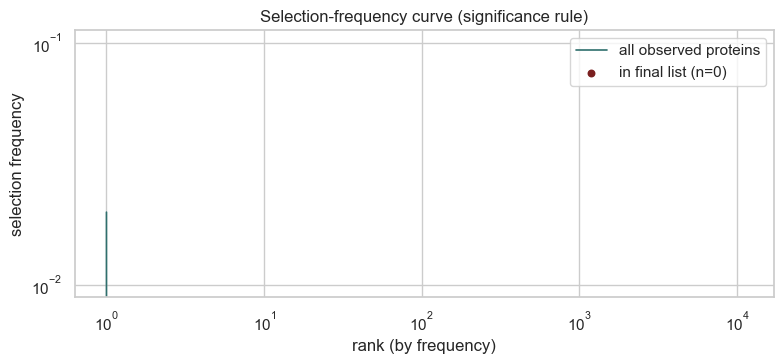

final-list proteins that appear in stability_significant: 0/0


In [35]:
curve = stab_sig.sort_values("frequency", ascending=False).reset_index(drop=True)
curve["rank"] = np.arange(1, len(curve) + 1)
curve["in_final_list"] = curve["protein_id"].isin(final_ids)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(curve["rank"], curve["frequency"], color=PALETTE["secondary"], lw=1.2, label="all observed proteins")
hit = curve[curve["in_final_list"]]
ax.scatter(hit["rank"], hit["frequency"], color=PALETTE["danger"], s=22, zorder=5,
           label=f"in final list (n={len(hit)})")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("rank (by frequency)")
ax.set_ylabel("selection frequency")
ax.set_title(f"Selection-frequency curve (significance rule)")
ax.legend()
fig.tight_layout()
plt.show()

n_final_observed = curve["in_final_list"].sum()
print(f"final-list proteins that appear in stability_significant: {n_final_observed}/{len(final_list)}")

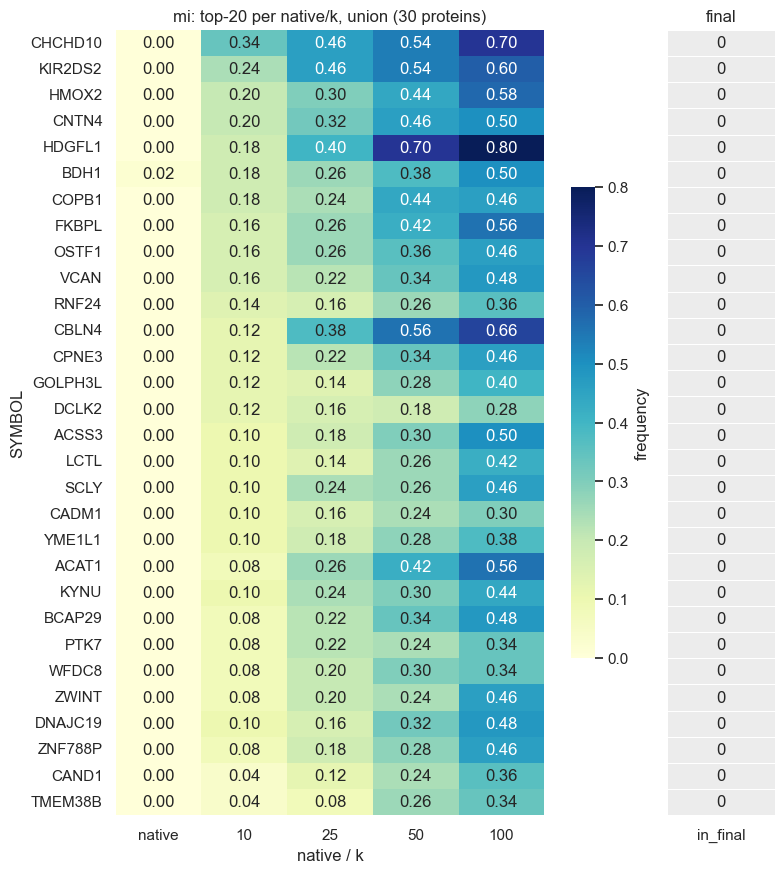

In [36]:
# Top-k/native frequency heatmap: union of the top-20 proteins at each k plus native,
# rows=proteins, cols=[native + k values], cells=frequency, with a final-list membership flag.
topN = 20
k_vals = sorted(stab_topk["k"].unique())
native_col = "native"

def _normalize_probe_id(value) -> str:
    probe = str(value).strip()
    if probe.startswith("seq."):
        probe = probe[4:]
    return probe.replace("_", "-").replace(".", "-")

ann_map = pd.read_csv(DATA_PROCESSED / "somalogic_annotation.csv", usecols=["PROBEID", "SYMBOL"])
ann_map["probe_norm"] = ann_map["PROBEID"].map(_normalize_probe_id)
symbol_lookup = (
    ann_map.dropna(subset=["SYMBOL"])
.drop_duplicates("probe_norm")
.set_index("probe_norm")["SYMBOL"]
)

top_union_k = (
    stab_topk.sort_values(["k", "frequency"], ascending=[True, False])
.groupby("k").head(topN)["protein_id"].tolist()
)
top_union_native = (
    stab_sig.sort_values("frequency", ascending=False)
.head(topN)["protein_id"].tolist()
)
top_union = list(dict.fromkeys(top_union_k + top_union_native))

mat = (stab_topk[stab_topk["protein_id"].isin(top_union)]
.pivot_table(index="protein_id", columns="k", values="frequency", fill_value=0)
.reindex(top_union))
mat[native_col] = mat.index.to_series().map(stab_sig.set_index("protein_id")["frequency"]).fillna(0.0)
mat["in_final"] = mat.index.to_series().isin(final_ids).astype(int)

display_cols = [native_col] + k_vals
row_labels = [symbol_lookup.get(_normalize_probe_id(pid), pid) for pid in mat.index]
mat_display = mat.copy()
mat_display.index = row_labels

fig, (ax_hm, ax_flag) = plt.subplots(
    1, 2, figsize=(1.1 * len(display_cols) + 3, 0.3 * len(mat_display) + 1.2),
    gridspec_kw={"width_ratios": [len(display_cols), 1], "wspace": 0.05},
)
sns.heatmap(
    mat_display[display_cols],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=mat_display[display_cols].values.max(),
    ax=ax_hm,
    cbar_kws={"shrink": 0.6, "label": "frequency"},
)
ax_hm.set_title(f"{METHOD}: top-{topN} per native/k, union ({len(mat_display)} proteins)")
ax_hm.set_xlabel("native / k")
ax_hm.set_ylabel("SYMBOL")

sns.heatmap(
    mat_display[["in_final"]],
    annot=True,
    fmt="d",
    cmap=["#ECECEC", PALETTE["danger"]],
    cbar=False,
    ax=ax_flag,
    linewidths=0.4,
    linecolor="white",
)
ax_flag.set_yticks([])
ax_flag.set_xlabel("")
ax_flag.set_title("final")
plt.show()

In [37]:
thresholds = [0.1, 0.2, 0.3, 0.5]

sig_counts = {f"freq>={t}": int((stab_sig["frequency"] >= t).sum()) for t in thresholds}
topk_counts = (
    stab_topk.groupby("k")
             .apply(lambda g: pd.Series({f"freq>={t}": int((g["frequency"] >= t).sum()) for t in thresholds}))
)
summary = pd.concat(
    [pd.DataFrame([sig_counts], index=["significant"]), topk_counts.rename(lambda k: f"top-{k}")]
)
print("Proteins crossing frequency thresholds:")
display(summary)

print("\nmean_rank / mean_score (significant rule):")
display(stab_sig[["frequency", "mean_rank", "mean_score"]].describe().round(3))

Proteins crossing frequency thresholds:


,freq>=0.1,freq>=0.2,freq>=0.3,freq>=0.5
significant,0,0,0,0
top-10,22,4,1,0
top-25,60,19,6,0
top-50,140,45,18,4
top-100,295,112,49,10



mean_rank / mean_score (significant rule):


,frequency,mean_rank,mean_score
count,10776.00,10776.000,10776.000
mean,0.00,5387.500,0.007
std,0.00,2159.507,0.007
min,0.00,121.760,0.000
25%,0.00,3862.025,0.002
50%,0.00,5417.470,0.005
75%,0.00,6876.300,0.010
max,0.02,10721.120,0.050


## 4. Final protein list and enrichment

The final list is `significant == True` in `full_data_ranking.parquet` â€” i.e. the method's selection when run on the full (non-resampled) cohort. Enrichment below is whatever was produced against that list.

In [38]:
def _normalize_probe_id(value) -> str:
    probe = str(value).strip()
    if probe.startswith("seq."):
        probe = probe[4:]
    return probe.replace("_", "-").replace(".", "-")

ann = pd.read_csv(DATA_PROCESSED / "somalogic_annotation.csv")
ann["probe_norm"] = ann["PROBEID"].map(_normalize_probe_id)

final = final_list.copy()
final["probe_norm"] = final["protein_id"].map(_normalize_probe_id)
final = final.merge(
    ann[["probe_norm", "SYMBOL", "UNIPROT", "GENENAME"]],
    on="probe_norm", how="left",
).drop(columns="probe_norm")

# Join resampling frequency so the reader sees how stable each final protein is.
final = final.merge(
    stab_sig[["protein_id", "frequency"]].rename(columns={"frequency": "resample_freq"}),
    on="protein_id", how="left",
)
final["resample_freq"] = final["resample_freq"].fillna(0.0)

print(f"{len(final)} final proteins | symbols mapped: {final['SYMBOL'].notna().sum()} | "
      f"mean resample frequency: {final['resample_freq'].mean():.3f}")
display(final[["rank", "protein_id", "SYMBOL", "GENENAME", "score", "q_value", "resample_freq"]]
        .round(4)
        .style.background_gradient(subset=["resample_freq"], cmap="YlGnBu"))

0 final proteins | symbols mapped: 0 | mean resample frequency: nan


,rank,protein_id,SYMBOL,GENENAME,score,q_value,resample_freq


In [46]:
TOP_K = 10  # change this to show a different top-k slice
RESAMPLE_FREQ_SOURCE = "topk"  # or "topk"

# Show the top-k proteins by rank, even if fewer than k are significant.
top_k = ranking.sort_values("rank").head(TOP_K).copy()
top_k["probe_norm"] = top_k["protein_id"].map(_normalize_probe_id)
top_k = top_k.merge(
    ann[["probe_norm", "SYMBOL", "UNIPROT", "GENENAME"]],
    on="probe_norm", how="left",
).drop(columns="probe_norm")

# Choose whether resample_freq comes from the stability curve or the top-k resampling table.
if RESAMPLE_FREQ_SOURCE == "stability":
    resample_freq_df = stab_sig[["protein_id", "frequency"]]
elif RESAMPLE_FREQ_SOURCE == "topk":
    resample_freq_df = stab_topk[stab_topk["k"] == TOP_K][["protein_id", "frequency"]]
else:
    raise ValueError("RESAMPLE_FREQ_SOURCE must be 'stability' or 'topk'")

top_k = top_k.merge(
    resample_freq_df.rename(columns={"frequency": "resample_freq"}),
    on="protein_id", how="left",
)
top_k["resample_freq"] = top_k["resample_freq"].fillna(0.0)

print(
    f"{len(top_k)} top proteins | significant among them: {top_k['significant'].sum()} | "
    f"resample source: {RESAMPLE_FREQ_SOURCE} | mean resample frequency: {top_k['resample_freq'].mean():.3f}"
)
display(
    top_k[["rank", "protein_id", "SYMBOL", "GENENAME", "score", "q_value", "significant", "resample_freq"]]
    .round(4)
    .style.background_gradient(subset=["resample_freq"], cmap="YlGnBu")
)

10 top proteins | significant among them: 0 | resample source: topk | mean resample frequency: 0.168


,rank,protein_id,SYMBOL,GENENAME,score,q_value,significant,resample_freq
0,0,seq.11270.17,CHCHD10,coiled-coil-helix-coiled-coil-helix domain containing 10,0.057500,0.764000,False,0.340000
1,1,seq.35175.115,BDH1,3-hydroxybutyrate dehydrogenase 1,0.057400,0.764000,False,0.180000
2,2,seq.18898.36,HDGFL1,HDGF like 1,0.057000,0.764000,False,0.180000
3,3,seq.29945.51,FKBPL,FKBP prolyl isomerase like,0.053200,0.764000,False,0.160000
4,4,seq.19118.47,OSTF1,osteoclast stimulating factor 1,0.053000,0.764000,False,0.160000
5,5,seq.19197.95,ACAT1,acetyl-CoA acetyltransferase 1,0.053000,0.764000,False,0.080000
6,6,seq.21537.33,SCLY,selenocysteine lyase,0.050800,0.764000,False,0.100000
7,7,seq.23692.19,ACSS3,acyl-CoA synthetase short chain family member 3,0.050400,0.764000,False,0.100000
8,8,seq.34273.55,COPB1,coat protein complex I subunit beta 1,0.050200,0.764000,False,0.180000
9,9,seq.2622.18,HMOX2,heme oxygenase 2,0.050100,0.764000,False,0.200000


In [40]:
with open(STAGE_DIRS["enrichment"] / "gene_list.json") as f:
    gene_list = json.load(f)

print(f"source: {gene_list['source']}  min_size={gene_list['min_size']}  "
      f"n_proteins={gene_list['n_proteins']}  n_genes={gene_list['n_genes']}")

enrich_proteins = set(gene_list["protein_ids"])
only_final = enrich_proteins ^ set(final["protein_id"])
if only_final:
    print(f"NOTE: {len(only_final)} proteins differ between final list and enrichment input: {sorted(only_final)[:10]}")
else:
    print("Enrichment input matches the final list exactly.")

source: topk_fallback  min_size=10  n_proteins=10  n_genes=10
NOTE: 10 proteins differ between final list and enrichment input: ['seq.11270.17', 'seq.18898.36', 'seq.19118.47', 'seq.19197.95', 'seq.21537.33', 'seq.23692.19', 'seq.2622.18', 'seq.29945.51', 'seq.34273.55', 'seq.35175.115']


In [41]:
libraries = sorted(p.name for p in STAGE_DIRS["enrichment"].iterdir() if p.is_dir() and not p.name.startswith("_"))
print("enrichment libraries:", libraries)

rows = []
for lib in libraries:
    bes_path = STAGE_DIRS["enrichment"] / lib / "bes_components.json"
    if not bes_path.exists():
        print(f"[skip] {lib}: bes_components.json missing")
        continue
    bes = load_meta(bes_path)
    rows.append({
        "library": lib,
        "gene_list_size": bes.get("gene_list_size"),
        "background_size": bes.get("background_size"),
        "bes_raw": bes.get("bes_raw"),
        "bes_z":   bes.get("bes_z"),
        "bes_p_emp": bes.get("bes_p_emp"),
        "n_significant_terms": bes.get("bes_components", {}).get("n_significant_terms"),
        "n_terms_input":       bes.get("bes_components", {}).get("n_terms_input"),
    })
bes_df = pd.DataFrame(rows)
bes_df.round(3).style.background_gradient(subset=["bes_z"], cmap="YlGnBu")

enrichment libraries: ['GO_Biological_Process_2025', 'KEGG_2026', 'Reactome_Pathways_2024']


,library,gene_list_size,background_size,bes_raw,bes_z,bes_p_emp,n_significant_terms,n_terms_input
0,GO_Biological_Process_2025,10,9511,23.408000,0.067000,0.337000,16,33
1,KEGG_2026,10,9511,7.336000,3.264000,0.014000,5,6
2,Reactome_Pathways_2024,10,9511,13.259000,1.256000,0.056000,3,55


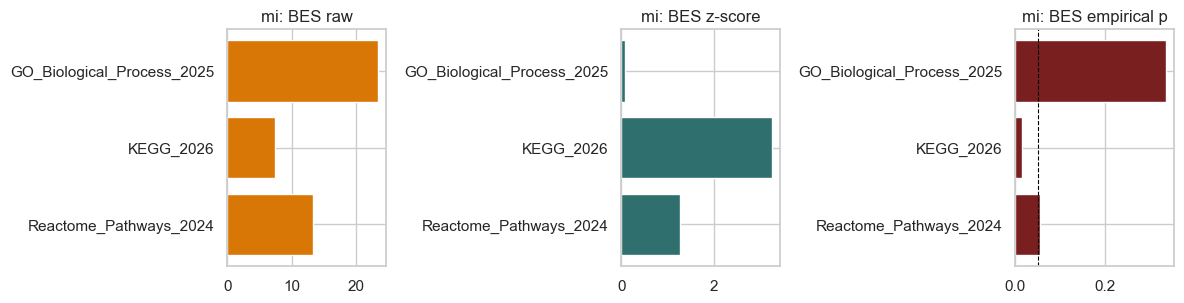

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, (metric, color, title) in zip(axes, [
    ("bes_raw", PALETTE["primary"],  "BES raw"),
    ("bes_z",   PALETTE["secondary"], "BES z-score"),
    ("bes_p_emp", PALETTE["danger"], "BES empirical p"),
]):
    ax.barh(bes_df["library"], bes_df[metric], color=color)
    ax.set_title(f"{METHOD}: {title}")
    ax.invert_yaxis()
axes[2].axvline(0.05, color="black", ls="--", lw=0.8)
fig.tight_layout()
plt.show()

In [43]:
TOP_N_TERMS = 20

with pd.option_context("display.max_colwidth", None):
    for lib in libraries:
        terms = pd.read_parquet(STAGE_DIRS["enrichment"] / lib / "terms.parquet")
        sig = terms[terms["q_value"] < 0.05].sort_values("q_value")
        print(f"\n### {lib}: {len(sig)} terms q<0.05 (of {len(terms)})")

        show = (sig if len(sig) else terms.sort_values("q_value")).head(TOP_N_TERMS)
        display(show[["term", "q_value", "p_value", "overlap_size", "term_size", "genes"]].round(4))


### GO_Biological_Process_2025: 16 terms q<0.05 (of 33)


,term,q_value,p_value,overlap_size,term_size,genes
0,Ketone Body Metabolic Process (GO:1902224),0.0297,0.0042,1,7.0,ACSS3
1,+ Reg of Mt Outer Membrane Permeabilization Inv in Apoptotic Sgnlng Pway (GO:1901030),0.0297,0.0052,1,7.0,CHCHD10
2,Heme Catabolic Process (GO:0042167),0.0297,0.0063,1,10.0,HMOX2
3,Maintenance of Synapse Structure (GO:0099558),0.0297,0.0063,1,8.0,CHCHD10
4,Pigment Catabolic Process (GO:0046149),0.0297,0.0063,1,10.0,HMOX2
5,Positive Regulation of Mitochondrial Membrane Permeability (GO:0035794),0.0297,0.0063,1,9.0,CHCHD10
6,Small Molecule Biosynthetic Process (GO:0044283),0.0297,0.0063,1,8.0,ACSS3
7,Porphyrin-Containing Compound Catabolic Process (GO:0006787),0.0346,0.0084,1,12.0,HMOX2
8,Reg of Mt Outer Membrane Permeabilization Inv in Apoptotic Sgnlng Pway (GO:1901028),0.0346,0.0094,1,20.0,CHCHD10
9,Cell Junction Maintenance (GO:0034331),0.0371,0.0115,1,17.0,CHCHD10



### KEGG_2026: 5 terms q<0.05 (of 6)


,term,q_value,p_value,overlap_size,term_size,genes
0,SELENOCOMPOUND METABOLISM,0.0328,0.0115,1,17.0,SCLY
1,BUTANOATE METABOLISM,0.0328,0.0146,1,27.0,BDH1
2,MINERAL ABSORPTION,0.0328,0.0208,1,58.0,HMOX2
3,PROPANOATE METABOLISM,0.0328,0.0219,1,32.0,ACSS3
4,PORPHYRIN METABOLISM,0.0398,0.0332,1,46.0,HMOX2



### Reactome_Pathways_2024: 3 terms q<0.05 (of 55)


,term,q_value,p_value,overlap_size,term_size,genes
0,Synthesis of Ketone Bodies,0.0000,0.0000,3,8.0,ACSS3;BDH1;ACAT1
1,Ketone Body Metabolism,0.0000,0.0000,3,10.0,ACSS3;BDH1;ACAT1
2,Mitochondrial Protein Degradation,0.0334,0.0018,2,97.0,BDH1;ACAT1
